# Nitrogen Shipping Failure: Thermodynamic Cycle Trace with CoolProp

**Objective** — Trace the complete thermodynamic state of the sealed nitrogen
charge through every segment of the air-transport shipping cycle using
[CoolProp](http://www.coolprop.org/) for real-gas properties, and demonstrate
quantitatively how irreversible mass loss during outbound venting leads to
return-leg underpressure.

Every variable — temperature, pressure, density, mass, bag volume, and their
rates of change — is computed at each timestep from first principles.
**Adjusting any parameter in the setup cells regenerates the entire analysis.**

In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 200)

print(f"CoolProp {CP.get_global_param_string('version')}")
print(f"NumPy {np.__version__}, Pandas {pd.__version__}")

CoolProp 7.2.0
NumPy 2.4.4, Pandas 3.0.2


# 1. System Parameters

All editable parameters for the nitrogen shipping system live in the next
cell.  Modify any value and re-run the notebook to explore a different
configuration.

| Symbol | Meaning |
|:-------|:--------|
| $V_{fixed}$ | Total rigid connected nitrogen volume (modules + tubing + manifolds) |
| $V_{bag,init}$ | Initial bag fill at seal-up |
| $V_{bag,max}$ | Maximum bag capacity (CALDRY 1500) |
| $T_{seal}$ | Temperature at seal-up |
| $P_{seal}$ | Ambient pressure at seal-up |
| $P_{crack,g}$ | Outward vent-valve cracking pressure (gauge) |

In [2]:
# ── System geometry ──────────────────────────────────────────────────
V_fixed_L    = 60.0     # Rigid connected volume (L) — THE CRITICAL UNKNOWN
V_bag_init_L = 11.0     # Initial bag fill at seal-up (L)
V_bag_max_L  = 22.0     # Maximum bag capacity (L) — CALDRY 1500

# ── Seal-up conditions ──────────────────────────────────────────────
T_seal_C     = 20.0     # Seal-up temperature (°C)
P_seal_atm   = 1.0      # Seal-up ambient pressure (atm, absolute)

# ── Vent valve ───────────────────────────────────────────────────────
P_crack_psig = 0.0      # Cracking pressure, gauge (psig). 0 = ideal vent.
# P_crack_psig = 2.0    # ← uncomment for 2-psig outward vent threshold

# ── Derived / unit conversions (do not edit) ─────────────────────────
ATM_TO_PA  = 101_325.0
PSIG_TO_PA = 6_894.76
L_TO_M3    = 1e-3

V_fixed    = V_fixed_L    * L_TO_M3       # m³
V_bag_init = V_bag_init_L * L_TO_M3       # m³
V_bag_max  = V_bag_max_L  * L_TO_M3       # m³
T_seal_K   = T_seal_C + 273.15            # K
P_seal_Pa  = P_seal_atm * ATM_TO_PA       # Pa
P_crack_Pa = P_crack_psig * PSIG_TO_PA    # Pa

print(f"V_fixed  = {V_fixed_L:.1f} L  ({V_fixed*1e3:.3f} dm³)")
print(f"V_bag    = {V_bag_init_L:.1f} → {V_bag_max_L:.1f} L")
print(f"Seal-up  = {T_seal_C:.0f} °C, {P_seal_atm:.3f} atm")
print(f"P_crack  = {P_crack_psig:.1f} psig ({P_crack_Pa:.0f} Pa)")

V_fixed  = 60.0 L  (60.000 dm³)
V_bag    = 11.0 → 22.0 L
Seal-up  = 20 °C, 1.000 atm
P_crack  = 0.0 psig (0 Pa)


# 2. Flight Profile

The shipping cycle is divided into discrete segments.  Each segment has a
duration, a linear temperature ramp, and a linear cabin-altitude ramp.
Cabin altitude determines ambient (cargo-hold) pressure via the
**International Standard Atmosphere (ISA)** barometric formula.

$$
P(h) = P_0 \left(1 - \frac{L\,h}{T_0}\right)^{\!\frac{g\,M}{R\,L}}
$$

| Constant | Value | Unit |
|:---------|------:|:-----|
| $P_0$ | 101 325 | Pa |
| $T_0$ | 288.15 | K |
| $L$ (lapse rate) | 0.0065 | K/m |
| $g$ | 9.806 65 | m/s² |
| $M_{air}$ | 0.028 964 4 | kg/mol |
| $R$ | 8.314 47 | J/(mol·K) |

**Edit the segment table in the next cell** to model a different route,
season, or multi-leg journey.

In [3]:
def isa_pressure_Pa(altitude_ft: float) -> float:
    # ISA tropospheric pressure (altitude in feet -> pressure in Pa).
    h_m = altitude_ft * 0.3048
    P0, T0, L = 101_325.0, 288.15, 0.0065   # Pa, K, K/m
    g, M, R_gas = 9.80665, 0.0289644, 8.31447
    return P0 * (1.0 - L * h_m / T0) ** (g * M / (R_gas * L))


# ── Flight-profile segments ─────────────────────────────────────────
# name, duration (hr), T start/end (°C), cabin-altitude start/end (ft)
segments = [
    {"name": "1. Ground transport to airport",
     "dur_hr": 1.0,  "T0_C": 20, "T1_C": 28, "alt0_ft": 0,    "alt1_ft": 0},

    {"name": "2. Tarmac / ULD wait (hot)",
     "dur_hr": 3.0,  "T0_C": 28, "T1_C": 40, "alt0_ft": 0,    "alt1_ft": 0},

    {"name": "3. Taxi & takeoff roll",
     "dur_hr": 0.25, "T0_C": 40, "T1_C": 38, "alt0_ft": 0,    "alt1_ft": 0},

    {"name": "4. Climb (cabin pressurisation)",
     "dur_hr": 0.42, "T0_C": 38, "T1_C": 24, "alt0_ft": 0,    "alt1_ft": 8000},

    {"name": "5. Cruise at altitude",
     "dur_hr": 10.0, "T0_C": 24, "T1_C": 24, "alt0_ft": 8000, "alt1_ft": 8000},

    {"name": "6. Descent (cabin depressurisation)",
     "dur_hr": 0.50, "T0_C": 24, "T1_C": 26, "alt0_ft": 8000, "alt1_ft": 0},

    {"name": "7. Taxi & unload",
     "dur_hr": 0.50, "T0_C": 26, "T1_C": 28, "alt0_ft": 0,    "alt1_ft": 0},

    {"name": "8. Ground transport to site",
     "dur_hr": 1.0,  "T0_C": 28, "T1_C": 22, "alt0_ft": 0,    "alt1_ft": 0},

    {"name": "9. Destination hold / cool-down",
     "dur_hr": 2.0,  "T0_C": 22, "T1_C": 20, "alt0_ft": 0,    "alt1_ft": 0},
]

# ── Segment summary table ───────────────────────────────────────────
rows = []
for s in segments:
    P0 = isa_pressure_Pa(s["alt0_ft"])
    P1 = isa_pressure_Pa(s["alt1_ft"])
    dur_min = s["dur_hr"] * 60
    dT = (s["T1_C"] - s["T0_C"]) / s["dur_hr"] if s["dur_hr"] > 0 else 0
    alt_rate = (s["alt1_ft"] - s["alt0_ft"]) / dur_min if dur_min > 0 else 0
    dP = (P1 - P0) / (s["dur_hr"] * 3600) if s["dur_hr"] > 0 else 0
    rows.append({
        "Segment": s["name"],
        "Duration": f"{dur_min:.0f} min" if dur_min < 120 else f"{s['dur_hr']:.1f} hr",
        "T start (°C)": s["T0_C"],
        "T end (°C)": s["T1_C"],
        "dT/dt (°C/hr)": f"{dT:+.1f}",
        "Alt₀ (ft)": f"{s['alt0_ft']:,}",
        "Alt₁ (ft)": f"{s['alt1_ft']:,}",
        "Alt rate (ft/min)": f"{alt_rate:+.0f}",
        "P₀ (kPa)": f"{P0/1000:.2f}",
        "P₁ (kPa)": f"{P1/1000:.2f}",
        "dP/dt (Pa/s)": f"{dP:+.2f}",
    })
display(pd.DataFrame(rows))

,Segment,Duration,T start (°C),T end (°C),dT/dt (°C/hr),Alt₀ (ft),Alt₁ (ft),Alt rate (ft/min),P₀ (kPa),P₁ (kPa),dP/dt (Pa/s)
0,1. Ground transport to airport,60 min,20,28,+8.0,0,0,+0,101.33,101.33,+0.00
1,2. Tarmac / ULD wait (hot),3.0 hr,28,40,+4.0,0,0,+0,101.33,101.33,+0.00
2,3. Taxi & takeoff roll,15 min,40,38,-8.0,0,0,+0,101.33,101.33,+0.00
3,4. Climb (cabin pressurisation),25 min,38,24,-33.3,0,"8,000",+317,101.33,75.26,-17.24
4,5. Cruise at altitude,10.0 hr,24,24,+0.0,"8,000","8,000",+0,75.26,75.26,+0.00
5,6. Descent (cabin depressurisation),30 min,24,26,+4.0,"8,000",0,-267,75.26,101.33,+14.48
6,7. Taxi & unload,30 min,26,28,+4.0,0,0,+0,101.33,101.33,+0.00
7,8. Ground transport to site,60 min,28,22,-6.0,0,0,+0,101.33,101.33,+0.00
8,9. Destination hold / cool-down,2.0 hr,22,20,-1.0,0,0,+0,101.33,101.33,+0.00


In [4]:
dt_hr = 1.0 / 60.0  # 1-minute resolution

t_list, T_list, P_list = [], [], []
seg_boundaries = [0]  # index of first timestep of each segment

t_cursor = 0.0
for s in segments:
    n_steps = max(int(round(s["dur_hr"] / dt_hr)), 1)
    for j in range(n_steps):
        frac = j / n_steps
        T_C   = s["T0_C"]   + frac * (s["T1_C"]   - s["T0_C"])
        alt_f = s["alt0_ft"] + frac * (s["alt1_ft"] - s["alt0_ft"])
        t_list.append(t_cursor + frac * s["dur_hr"])
        T_list.append(T_C + 273.15)
        P_list.append(isa_pressure_Pa(alt_f))
    t_cursor += s["dur_hr"]
    seg_boundaries.append(len(t_list))

# Final endpoint
t_list.append(t_cursor)
T_list.append(segments[-1]["T1_C"] + 273.15)
P_list.append(isa_pressure_Pa(segments[-1]["alt1_ft"]))

t_hr    = np.array(t_list)
T_K     = np.array(T_list)
P_amb   = np.array(P_list)

print(f"Profile built: {len(t_hr)} timesteps over {t_hr[-1]:.2f} hr")
print(f"Segment boundaries (indices): {seg_boundaries}")

Profile built: 1121 timesteps over 18.67 hr
Segment boundaries (indices): [0, 60, 240, 255, 280, 880, 910, 940, 1000, 1120]


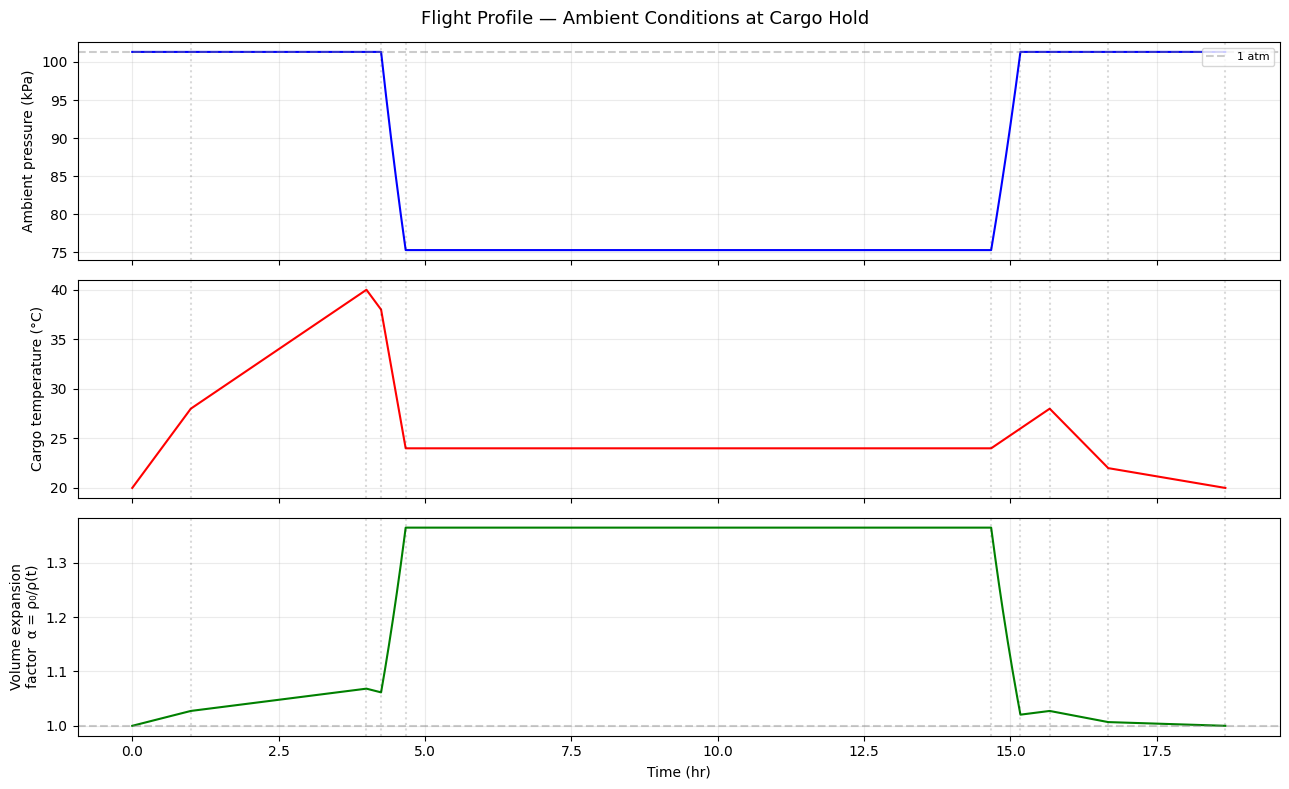

Peak expansion factor: α = 1.3648 at t = 4.67 hr
  (T = 24.0 °C,  P = 75.26 kPa)


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

axes[0].plot(t_hr, P_amb / 1000, "b-", lw=1.5)
axes[0].axhline(101.325, color="gray", ls="--", alpha=0.4, label="1 atm")
axes[0].set_ylabel("Ambient pressure (kPa)")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].plot(t_hr, T_K - 273.15, "r-", lw=1.5)
axes[1].set_ylabel("Cargo temperature (°C)")

# Volume-expansion factor relative to seal-up
rho_seal = CP.PropsSI("D", "T", T_seal_K, "P", P_seal_Pa, "Nitrogen")
alpha_arr = np.array([
    rho_seal / CP.PropsSI("D", "T", T_K[i], "P", P_amb[i], "Nitrogen")
    for i in range(len(t_hr))
])
axes[2].plot(t_hr, alpha_arr, "g-", lw=1.5)
axes[2].axhline(1.0, color="gray", ls="--", alpha=0.4)
axes[2].set_ylabel("Volume expansion\nfactor  α = ρ₀/ρ(t)")
axes[2].set_xlabel("Time (hr)")

for ax in axes:
    for b in seg_boundaries:
        if 0 < b < len(t_hr):
            ax.axvline(t_hr[b], color="k", ls=":", alpha=0.15)
    ax.grid(True, alpha=0.25)

fig.suptitle("Flight Profile — Ambient Conditions at Cargo Hold", fontsize=13)
fig.tight_layout()
plt.show()

i_peak = int(np.argmax(alpha_arr))
print(f"Peak expansion factor: α = {alpha_arr[i_peak]:.4f} at t = {t_hr[i_peak]:.2f} hr")
print(f"  (T = {T_K[i_peak]-273.15:.1f} °C,  P = {P_amb[i_peak]/1000:.2f} kPa)")

# 3. CoolProp Validation: Real Gas vs Ideal Gas

Before proceeding, we confirm that CoolProp's Helmholtz equation of state
for nitrogen agrees closely with the ideal gas law at the conditions in
this analysis.  The value of using CoolProp is not a large numerical
correction, but rather:

1. **Authority** — the analysis uses a peer-reviewed EOS, not an
   unverified assumption.
2. **Extensibility** — the framework remains valid if the analysis is
   later extended to colder temperatures, higher pressures, or gas
   mixtures.
3. **Completeness** — CoolProp provides entropy, enthalpy, heat capacity,
   and viscosity at every state point without additional models.

In [6]:
R_univ = 8.31446    # J/(mol·K)
M_N2   = 0.0280134  # kg/mol
R_spec = R_univ / M_N2

conditions = [
    ("Seal-up (20 °C, 1 atm)",  T_seal_K,  P_seal_Pa),
    ("Hot tarmac (40 °C, 1 atm)", 313.15,   ATM_TO_PA),
    ("Altitude (24 °C, 0.75 atm)", 297.15,  isa_pressure_Pa(8000)),
    ("Cold return (20 °C, 1 atm)", 293.15,   ATM_TO_PA),
]

rows = []
for label, T, P in conditions:
    rho_cp = CP.PropsSI("D", "T", T, "P", P, "Nitrogen")
    Z      = CP.PropsSI("Z", "T", T, "P", P, "Nitrogen")
    h      = CP.PropsSI("H", "T", T, "P", P, "Nitrogen")
    s      = CP.PropsSI("S", "T", T, "P", P, "Nitrogen")
    cp     = CP.PropsSI("C", "T", T, "P", P, "Nitrogen")
    cv     = CP.PropsSI("O", "T", T, "P", P, "Nitrogen")
    rho_ig = P / (R_spec * T)
    rows.append({
        "State": label,
        "T (K)": f"{T:.2f}",
        "P (kPa)": f"{P/1000:.2f}",
        "ρ_CP (kg/m³)": f"{rho_cp:.6f}",
        "ρ_ideal (kg/m³)": f"{rho_ig:.6f}",
        "Z": f"{Z:.6f}",
        "Err (ppm)": f"{abs(rho_cp - rho_ig)/rho_ig * 1e6:.1f}",
        "h (kJ/kg)": f"{h/1000:.2f}",
        "s (J/kg·K)": f"{s:.2f}",
        "γ = cₚ/cᵥ": f"{cp/cv:.4f}",
    })
display(pd.DataFrame(rows))
display(Markdown(
    "All compressibility factors Z are within 250 ppm of unity — nitrogen "
    "behaves as an ideal gas at these conditions. CoolProp **confirms** "
    "this quantitatively rather than assuming it."
))

,State,T (K),P (kPa),ρ_CP (kg/m³),ρ_ideal (kg/m³),Z,Err (ppm),h (kJ/kg),s (J/kg·K),γ = cₚ/cᵥ
0,"Seal-up (20 °C, 1 atm)",293.15,101.33,1.164830,1.164551,0.999757,239.8,304.06,6817.68,1.4014
1,"Hot tarmac (40 °C, 1 atm)",313.15,101.33,1.090260,1.090174,0.999918,78.9,324.89,6886.41,1.4009
2,"Altitude (24 °C, 0.75 atm)",297.15,75.26,0.853497,0.853368,0.999846,151.1,308.28,6920.23,1.4009
3,"Cold return (20 °C, 1 atm)",293.15,101.33,1.164830,1.164551,0.999757,239.8,304.06,6817.68,1.4014


All compressibility factors Z are within 250 ppm of unity — nitrogen behaves as an ideal gas at these conditions. CoolProp **confirms** this quantitatively rather than assuming it.

# 4. Governing Equations

## State equation (CoolProp Helmholtz EOS)

At each timestep the nitrogen density is obtained from the Span–Lemmon–
Jacobsen–Wagner equation of state implemented in CoolProp:

$$
\rho(T, P) = \text{CoolProp}\!\left(\texttt{"D"},\; T,\; P,\; \text{N}_2\right)
$$

For a retained mass $m$ the required total volume at ambient pressure is

$$
V_{req}(t) = \frac{m(t)}{\rho\!\bigl(T(t),\, P_{amb}(t)\bigr)}
$$

## Bag volume constraint

$$
V_{bag}(t) = \text{clamp}\!\bigl(V_{req}(t) - V_{fixed},\; 0,\; V_{bag,max}\bigr)
$$

## Piecewise pressure logic

| Condition | Internal pressure | Action |
|:----------|:-----------------|:-------|
| $0 \le V_{bag,req} \le V_{bag,max}$ | $P_{int} = P_{amb}$ | Bag accommodates |
| $V_{bag,req} > V_{bag,max}$ | $P_{int} = P\!\bigl(T,\, m/(V_{fixed}+V_{bag,max})\bigr)$ | If $P_{int} > P_{amb}+P_{crack}$: **vent** to $P_{vent}$ |
| $V_{bag,req} < 0$ | $P_{int} = P\!\bigl(T,\, m/V_{fixed}\bigr)$ | **Bag collapsed** — $\Delta P < 0$ |

## Venting (irreversible mass loss)

$$
\rho_{vent} = \rho\!\bigl(T,\; P_{amb}+P_{crack}\bigr),
\qquad
m^{+} = \rho_{vent}\,\bigl(V_{fixed}+V_{bag,max}\bigr)
$$

$$
\Delta m_{vent} = m - m^{+} > 0 \quad\text{(nitrogen permanently lost)}
$$

## Rate equations

**Isobaric heating** ($dP_{amb}/dt = 0$):

$$
\frac{dV_{bag}}{dt}
= -\frac{m}{\rho^2}\!\left(\frac{\partial\rho}{\partial T}\right)_{\!P}\,\frac{dT}{dt}
\;\approx\; \frac{V_{req}}{T}\,\frac{dT}{dt}
$$

**Isothermal depressurisation** ($dT/dt = 0$):

$$
\frac{dV_{bag}}{dt}
= -\frac{m}{\rho^2}\!\left(\frac{\partial\rho}{\partial P}\right)_{\!T}\,\frac{dP_{amb}}{dt}
\;\approx\; -\frac{V_{req}}{P_{amb}}\,\frac{dP_{amb}}{dt}
$$

The ideal-gas approximations (right-hand sides) are shown for intuition;
the simulation uses CoolProp at every step.

In [20]:
def simulate(t_hr, T_K, P_amb_Pa, V_fixed, V_bag_init, V_bag_max, P_crack_Pa):
    # Full quasi-static cycle simulation using CoolProp at every timestep.
    # Returns a dict of arrays aligned with t_hr.
    n = len(t_hr)

    # ── Initial state ────────────────────────────────────────────────
    rho_0 = CP.PropsSI("D", "T", T_K[0], "P", P_amb_Pa[0], "Nitrogen")
    m = rho_0 * (V_fixed + V_bag_init)          # initial mass (kg)

    # ── Allocate result arrays ───────────────────────────────────────
    P_int     = np.zeros(n)
    V_bag     = np.zeros(n)
    mass      = np.zeros(n)
    rho_int   = np.zeros(n)
    delta_P   = np.zeros(n)
    cum_vent  = np.zeros(n)
    Z_arr     = np.zeros(n)
    h_arr     = np.zeros(n)
    s_arr     = np.zeros(n)

    total_vented = 0.0

    for i in range(n):
        T  = T_K[i]
        Pa = P_amb_Pa[i]

        # Volume the current mass needs at ambient pressure
        rho_amb   = CP.PropsSI("D", "T", T, "P", Pa, "Nitrogen")
        V_req     = m / rho_amb
        V_bag_req = V_req - V_fixed

        if 0 <= V_bag_req <= V_bag_max:
            # ── Bag accommodates ──
            P_int[i]   = Pa
            V_bag[i]   = V_bag_req
            rho_int[i] = rho_amb

        elif V_bag_req > V_bag_max:
            # ── Bag full → pressure rises ──
            V_tot = V_fixed + V_bag_max
            rho_i = m / V_tot
            P_i   = CP.PropsSI("P", "T", T, "D", rho_i, "Nitrogen")

            P_vent = Pa + P_crack_Pa if P_crack_Pa > 0 else Pa

            if P_i > P_vent:
                # Vent to setpoint
                rho_v = CP.PropsSI("D", "T", T, "P", P_vent, "Nitrogen")
                m_new = rho_v * V_tot
                total_vented += (m - m_new)
                m = m_new
                P_int[i]   = P_vent
                rho_int[i] = rho_v
            else:
                P_int[i]   = P_i
                rho_int[i] = rho_i
            V_bag[i] = V_bag_max

        else:
            # ── Bag collapsed ──
            rho_i = m / V_fixed
            P_i   = CP.PropsSI("P", "T", T, "D", rho_i, "Nitrogen")
            P_int[i]   = P_i
            V_bag[i]   = 0.0
            rho_int[i] = rho_i

        mass[i]     = m
        delta_P[i]  = P_int[i] - Pa
        cum_vent[i] = total_vented
        Z_arr[i]    = CP.PropsSI("Z", "T", T, "P", abs(P_int[i]), "Nitrogen")
        h_arr[i]    = CP.PropsSI("H", "T", T, "P", abs(P_int[i]), "Nitrogen")
        s_arr[i]    = CP.PropsSI("S", "T", T, "P", abs(P_int[i]), "Nitrogen")

    return dict(
        t_hr=t_hr, T_K=T_K, P_amb_Pa=P_amb_Pa,
        P_int_Pa=P_int, V_bag_m3=V_bag, mass_kg=mass,
        rho_int=rho_int, delta_P_Pa=delta_P,
        cum_vent_kg=cum_vent, Z=Z_arr, h_J_kg=h_arr, s_J_kgK=s_arr,
    )

print("simulate() defined — CoolProp-backed quasi-static engine ready.")

simulate() defined — CoolProp-backed quasi-static engine ready.


In [21]:
# ── Reusable display helpers ──────────────────────────────────────────

def state_table(result, indices, labels):
    # Build a pandas DataFrame of thermodynamic properties at given indices.
    rows = []
    for idx, label in zip(indices, labels):
        if idx is None:
            continue
        r = result
        rows.append({
            "State": label,
            "t (hr)": f"{r['t_hr'][idx]:.2f}",
            "T (°C)": f"{r['T_K'][idx]-273.15:.1f}",
            "P_amb (kPa)": f"{r['P_amb_Pa'][idx]/1000:.2f}",
            "P_int (kPa)": f"{r['P_int_Pa'][idx]/1000:.2f}",
            "ΔP (Pa)": f"{r['delta_P_Pa'][idx]:+.1f}",
            "ρ (kg/m³)": f"{r['rho_int'][idx]:.4f}",
            "V_bag (L)": f"{r['V_bag_m3'][idx]*1000:.2f}",
            "m_N₂ (g)": f"{r['mass_kg'][idx]*1000:.4f}",
            "Vented (g)": f"{r['cum_vent_kg'][idx]*1000:.4f}",
            "Z": f"{r['Z'][idx]:.6f}",
        })
    return pd.DataFrame(rows)


def show_state_eqns(result, idx, V_fixed_L):
    # Display the governing equation with numerical values substituted.
    T   = result["T_K"][idx]
    Pa  = result["P_amb_Pa"][idx]
    Pi  = result["P_int_Pa"][idx]
    rho = result["rho_int"][idx]
    m   = result["mass_kg"][idx]
    Vb  = result["V_bag_m3"][idx] * 1000   # L
    Vr  = m / rho * 1000                   # L

    lines = [
        f"**State at $t = {result['t_hr'][idx]:.2f}$ hr**  "
        f"($T = {T-273.15:.1f}$ °C, $P_{{amb}} = {Pa/1000:.2f}$ kPa)\n",
        "$$",
        fr"\rho = \rho_{{\text{{CP}}}}({T:.2f}\;\text{{K}},\;"
        f"{Pa/1000:.2f}\\;\\text{{kPa}}) = {rho:.4f}\\;\\text{{kg/m³}}",
        "$$\n",
        "$$",
        f"V_{{req}} = \\frac{{m}}{{\\rho}} = "
        f"\\frac{{{m*1000:.4f}\\;\\text{{g}}}}"
        f"{{{rho:.4f}\\;\\text{{kg/m³}}}} = "
        f"{Vr:.2f}\\;\\text{{L}}",
        "$$\n",
        "$$",
        f"V_{{bag}} = V_{{req}} - V_{{fixed}} = "
        f"{Vr:.2f} - {V_fixed_L:.1f} = {Vb:.2f}\\;\\text{{L}}",
        "$$\n",
    ]

    if Vb >= V_bag_max_L - 0.01:
        lines.append(f"> **Bag is at maximum capacity** ({V_bag_max_L:.0f} L).")
        if Pi > Pa + 1.0:
            lines.append(
                f"  Internal overpressure: "
                f"$\\Delta P = {(Pi-Pa):.1f}$ Pa = {(Pi-Pa)/1000:.4f} kPa."
            )
    elif Vb <= 0.01:
        lines.append(
            f"> **Bag has collapsed.**  $P_{{int}} = {Pi/1000:.2f}$ kPa, "
            f"$\\Delta P = {Pi-Pa:+.1f}$ Pa."
        )
    else:
        lines.append(
            f"> Bag within operating range.  "
            f"$P_{{int}} = P_{{amb}} = {Pi/1000:.2f}$ kPa."
        )

    display(Markdown("\n".join(lines)))


def phase_plot(result, i0, i1, title=""):
    # Four-panel plot of key variables over a time slice.
    sl = slice(i0, i1 + 1)
    t  = result["t_hr"][sl]

    fig, axes = plt.subplots(2, 2, figsize=(13, 6), sharex=True)

    axes[0, 0].plot(t, result["P_int_Pa"][sl]/1000, "b-", label="P_int")
    axes[0, 0].plot(t, result["P_amb_Pa"][sl]/1000, "b--", alpha=.4, label="P_amb")
    axes[0, 0].set_ylabel("Pressure (kPa)")
    axes[0, 0].legend(fontsize=8)

    axes[0, 1].plot(t, result["V_bag_m3"][sl]*1000, "g-")
    axes[0, 1].axhline(V_bag_max_L, color="r", ls="--", alpha=.4,
                        label=f"V_bag_max = {V_bag_max_L} L")
    axes[0, 1].axhline(0, color="k", alpha=.2)
    axes[0, 1].set_ylabel("Bag volume (L)")
    axes[0, 1].legend(fontsize=8)

    axes[1, 0].plot(t, result["mass_kg"][sl]*1000, "m-")
    axes[1, 0].set_ylabel("N₂ mass (g)")
    axes[1, 0].set_xlabel("Time (hr)")

    axes[1, 1].plot(t, result["delta_P_Pa"][sl], "r-")
    axes[1, 1].axhline(0, color="k", lw=1)
    axes[1, 1].set_ylabel("ΔP (Pa)")
    axes[1, 1].set_xlabel("Time (hr)")

    for ax in axes.flat:
        ax.grid(True, alpha=.25)

    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()

print("Display helpers ready: state_table(), show_state_eqns(), phase_plot()")

Display helpers ready: state_table(), show_state_eqns(), phase_plot()


In [22]:
result = simulate(t_hr, T_K, P_amb, V_fixed, V_bag_init, V_bag_max, P_crack_Pa)

# ── Identify key events ──────────────────────────────────────────────
i_seal       = 0
i_bag_full   = next((i for i in range(len(t_hr)) if result["V_bag_m3"][i] >= V_bag_max - 1e-9), None)
i_vent_start = next((i for i in range(len(t_hr)) if result["cum_vent_kg"][i] > 0), None)
i_bag_collapse = None
for i in range(1, len(t_hr)):
    if result["V_bag_m3"][i] <= 1e-9 and result["V_bag_m3"][i-1] > 1e-9:
        i_bag_collapse = i
        break
i_worst = int(np.argmin(result["delta_P_Pa"]))
i_final = len(t_hr) - 1

events = {
    "Seal-up":      i_seal,
    "Bag full":     i_bag_full,
    "Vent start":   i_vent_start,
    "Bag collapse": i_bag_collapse,
    "Worst ΔP":     i_worst,
    "Final":        i_final,
}

print("KEY EVENTS")
print("-" * 85)
for name, idx in events.items():
    if idx is not None:
        t = result["t_hr"][idx]
        dp = result["delta_P_Pa"][idx]
        vb = result["V_bag_m3"][idx] * 1000
        mg = result["mass_kg"][idx] * 1000
        vg = result["cum_vent_kg"][idx] * 1000
        print(f"  {name:15s}  t={t:6.2f} hr  ΔP={dp:+8.1f} Pa  "
              f"V_bag={vb:5.2f} L  m={mg:.4f} g  vented={vg:.4f} g")
    else:
        print(f"  {name:15s}  — (does not occur)")

KEY EVENTS
-------------------------------------------------------------------------------------
  Seal-up          t=  0.00 hr  ΔP=    +0.0 Pa  V_bag=11.00 L  m=82.7029 g  vented=0.0000 g
  Bag full         t=  4.40 hr  ΔP=    +0.0 Pa  V_bag=22.00 L  m=82.3349 g  vented=0.3681 g
  Vent start       t=  4.40 hr  ΔP=    +0.0 Pa  V_bag=22.00 L  m=82.3349 g  vented=0.3681 g
  Bag collapse     — (does not occur)
  Worst ΔP         t=  0.00 hr  ΔP=    +0.0 Pa  V_bag=11.00 L  m=82.7029 g  vented=0.0000 g
  Final            t= 18.67 hr  ΔP=    +0.0 Pa  V_bag= 0.08 L  m=69.9867 g  vented=12.7162 g


# 5. Step-by-Step Thermodynamic Walkthrough

## Phase 1 — Ground Operations (Isobaric Heating)

**Segments 1–3:** Assembly → ground transport → tarmac wait → taxi.
Throughout this phase $P_{amb} = P_0 = 101.325$ kPa (sea level) and the
bag absorbs thermal expansion.

**Governing process — isobaric heating:**

$$
m = m_0 = \text{const} \qquad\text{(no venting possible at } P_{int} \le P_{amb}\text{)}
$$

$$
V_{req}(T) = \frac{m_0}{\rho(T,\,P_0)},
\qquad V_{bag}(T) = V_{req}(T) - V_{fixed}
$$

**Rate of bag expansion** at constant pressure:

$$
\frac{dV_{bag}}{dt}
= -\frac{m_0}{\rho^2}\left(\frac{\partial\rho}{\partial T}\right)_{\!P}
  \frac{dT}{dt}
\approx \frac{V_{req}}{T}\,\frac{dT}{dt}
$$

### Phase 1 — State Table

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,Seal-up,0.00,20.0,101.33,101.33,+0.0,1.1648,11.00,82.7029,0.0000,0.999757
1,End ground transport,1.00,28.0,101.33,101.33,+0.0,1.1338,12.94,82.7029,0.0000,0.999827
2,End tarmac wait,4.00,40.0,101.33,101.33,+0.0,1.0903,15.86,82.7029,0.0000,0.999918
3,End taxi,4.23,38.1,101.33,101.33,+0.0,1.0968,15.40,82.7029,0.0000,0.999905


### Substituted equations

**State at $t = 0.00$ hr**  ($T = 20.0$ °C, $P_{amb} = 101.33$ kPa)

$$
\rho = \rho_{\text{CP}}(293.15\;\text{K},\;101.33\;\text{kPa}) = 1.1648\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{82.7029\;\text{g}}{1.1648\;\text{kg/m³}} = 71.00\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 71.00 - 60.0 = 11.00\;\text{L}
$$

> Bag within operating range.  $P_{int} = P_{amb} = 101.33$ kPa.

**State at $t = 4.23$ hr**  ($T = 38.1$ °C, $P_{amb} = 101.33$ kPa)

$$
\rho = \rho_{\text{CP}}(311.28\;\text{K},\;101.33\;\text{kPa}) = 1.0968\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{82.7029\;\text{g}}{1.0968\;\text{kg/m³}} = 75.40\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 75.40 - 60.0 = 15.40\;\text{L}
$$

> Bag within operating range.  $P_{int} = P_{amb} = 101.33$ kPa.

### Rate of bag expansion during tarmac heating

At $t = 2.50$ hr  ($T = 34.0$ °C):

$$
\left(\frac{\partial\rho}{\partial T}\right)_{\!P}
= -0.003628\;\text{kg/(m³·K)}
\quad\text{(CoolProp, numerical)}
$$

$$
\frac{dV_{bag}}{dt}
= -\frac{m_0}{\rho^2}
  \left(\frac{\partial\rho}{\partial T}\right)_{\!P}
  \frac{dT}{dt}
= 0.971\;\text{L/hr}
$$

$$
\frac{dV_{bag}}{dt}
\approx \frac{V_{req}}{T}\,\frac{dT}{dt}
= \frac{74.40}{307.15} \times 4.0
= 0.969\;\text{L/hr  (ideal-gas check)}
$$


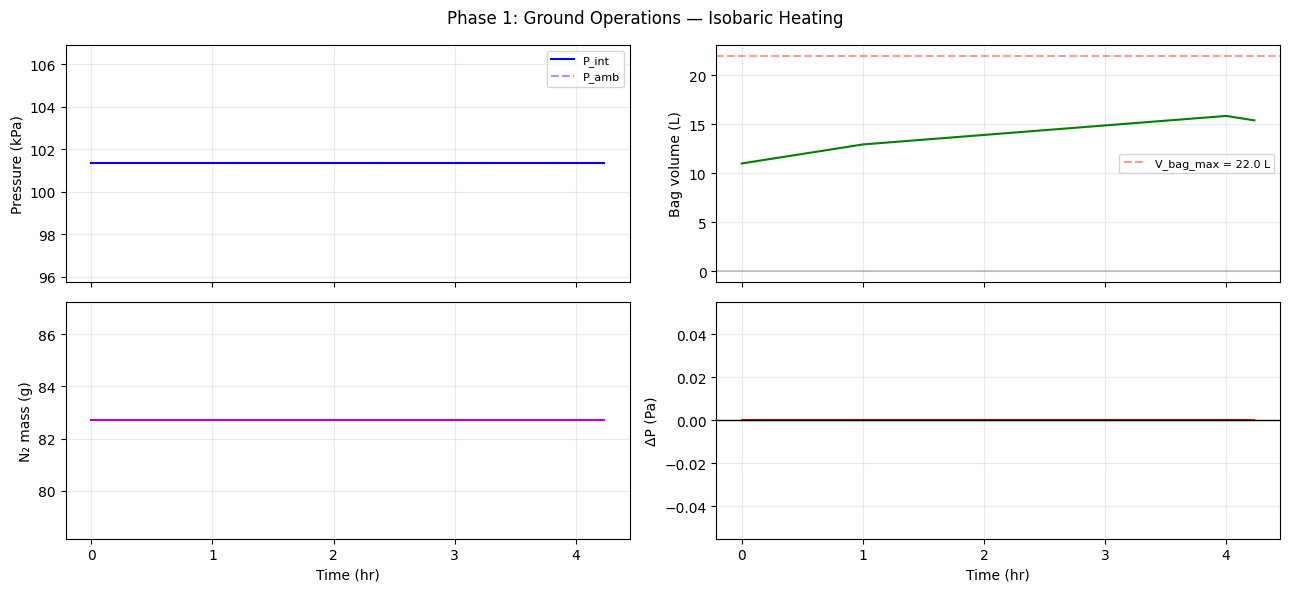

In [10]:
i_p1_start = 0
i_p1_end   = seg_boundaries[3] - 1   # end of segment 3 (taxi)

display(Markdown("### Phase 1 — State Table"))
display(state_table(result,
    [0, seg_boundaries[1], seg_boundaries[2], i_p1_end],
    ["Seal-up", "End ground transport", "End tarmac wait", "End taxi"]))

display(Markdown("### Substituted equations"))
show_state_eqns(result, 0, V_fixed_L)
show_state_eqns(result, i_p1_end, V_fixed_L)

# ── Rate calculation during main heating (tarmac segment) ────────────
i_mid  = (seg_boundaries[1] + seg_boundaries[2]) // 2
T_mid  = result["T_K"][i_mid]
rho_m  = result["rho_int"][i_mid]
m0_g   = result["mass_kg"][0] * 1000
V_req_m = result["mass_kg"][0] / rho_m * 1000  # L
dT_dt  = (40 - 28) / 3.0   # °C/hr during tarmac

# Numerical partial derivative via CoolProp
eps_T = 0.5  # K
drho_dT = (
    CP.PropsSI("D", "T", T_mid + eps_T, "P", P_seal_Pa, "Nitrogen")
  - CP.PropsSI("D", "T", T_mid - eps_T, "P", P_seal_Pa, "Nitrogen")
) / (2 * eps_T)
dVbag_dt_exact = -(result["mass_kg"][0] / rho_m**2) * drho_dT * (dT_dt / 3600) * 1000 * 3600  # L/hr
dVbag_dt_ideal = V_req_m / T_mid * dT_dt  # L/hr (ideal gas approx)

display(Markdown(f"""### Rate of bag expansion during tarmac heating

At $t = {result['t_hr'][i_mid]:.2f}$ hr  ($T = {T_mid-273.15:.1f}$ °C):

$$
\\left(\\frac{{\\partial\\rho}}{{\\partial T}}\\right)_{{\\!P}}
= {drho_dT:.6f}\\;\\text{{kg/(m³·K)}}
\\quad\\text{{(CoolProp, numerical)}}
$$

$$
\\frac{{dV_{{bag}}}}{{dt}}
= -\\frac{{m_0}}{{\\rho^2}}
  \\left(\\frac{{\\partial\\rho}}{{\\partial T}}\\right)_{{\\!P}}
  \\frac{{dT}}{{dt}}
= {dVbag_dt_exact:.3f}\\;\\text{{L/hr}}
$$

$$
\\frac{{dV_{{bag}}}}{{dt}}
\\approx \\frac{{V_{{req}}}}{{T}}\\,\\frac{{dT}}{{dt}}
= \\frac{{{V_req_m:.2f}}}{{{T_mid:.2f}}} \\times {dT_dt:.1f}
= {dVbag_dt_ideal:.3f}\\;\\text{{L/hr  (ideal-gas check)}}
$$
"""))

phase_plot(result, i_p1_start, i_p1_end, "Phase 1: Ground Operations — Isobaric Heating")

## Phase 2 — Climb (Simultaneous Depressurisation + Cooling)

**Segment 4:** The aircraft climbs and the cabin pressurisation system
allows cabin altitude to rise from 0 to 8 000 ft over ≈ 25 min.
Simultaneously the cargo hold cools from tarmac temperature toward the
conditioned hold set-point.

Both changes drive the gas to expand — lower ambient pressure and (for
the cooling) higher specific volume relative to the still-hot condition
at takeoff.

**Cabin-altitude rate:**

$$
\frac{d(\text{alt})}{dt} = \frac{8\,000\;\text{ft}}{25\;\text{min}}
= 320\;\text{ft/min}
$$

This is within the EASA/FAA passenger-comfort limit of ≈ 500 ft/min.

**If the bag saturates during climb, venting begins and the mass
inventory starts to decline — this is the irreversible step.**

### Phase 2 — State Table

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,Start of climb,4.25,38.0,101.33,101.33,+0.0,1.0973,15.37,82.7029,0.0000,0.999904
1,Mid-climb,4.45,31.3,88.03,88.03,+0.0,0.9744,22.00,79.9014,2.8015,0.999872
2,Top of climb,4.65,24.6,76.19,76.19,+0.0,0.8624,22.00,70.7140,11.9889,0.999848


**State at $t = 4.65$ hr**  ($T = 24.6$ °C, $P_{amb} = 76.19$ kPa)

$$
\rho = \rho_{\text{CP}}(297.71\;\text{K},\;76.19\;\text{kPa}) = 0.8624\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{70.7140\;\text{g}}{0.8624\;\text{kg/m³}} = 82.00\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 82.00 - 60.0 = 22.00\;\text{L}
$$

> **Bag is at maximum capacity** (22 L).

### ⚠ Venting begins during climb

First vent at $t = 4.40$ hr.  Mass vented by top of climb: **11.9889 g**.

### Rates during climb

| Rate | Value |
|:-----|------:|
| Cabin altitude rate | 320 ft/min |
| $dP_{amb}/dt$ | -17.32 Pa/s |
| $dT/dt$ | +33.3 °C/hr |


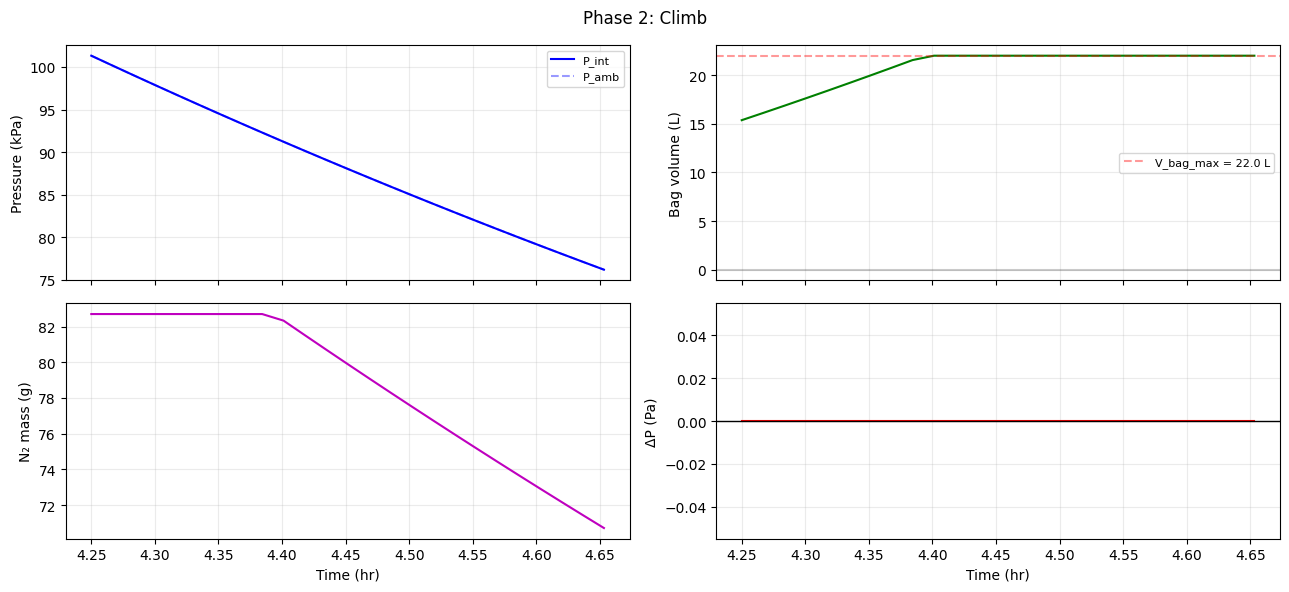

In [11]:
i_p2_start = seg_boundaries[3]
i_p2_end   = seg_boundaries[4] - 1
i_p2_mid   = (i_p2_start + i_p2_end) // 2

display(Markdown("### Phase 2 — State Table"))
display(state_table(result,
    [i_p2_start, i_p2_mid, i_p2_end],
    ["Start of climb", "Mid-climb", "Top of climb"]))

show_state_eqns(result, i_p2_end, V_fixed_L)

# Venting during climb?
if i_vent_start is not None and i_p2_start <= i_vent_start <= i_p2_end:
    dm = result["cum_vent_kg"][i_p2_end] * 1000
    display(Markdown(
        f"### ⚠ Venting begins during climb\n\n"
        f"First vent at $t = {t_hr[i_vent_start]:.2f}$ hr.  "
        f"Mass vented by top of climb: **{dm:.4f} g**."))

# Pressure-rate during climb
dP_dt_climb = (P_amb[i_p2_end] - P_amb[i_p2_start]) / \
              ((t_hr[i_p2_end] - t_hr[i_p2_start]) * 3600)
display(Markdown(f"""### Rates during climb

| Rate | Value |
|:-----|------:|
| Cabin altitude rate | 320 ft/min |
| $dP_{{amb}}/dt$ | {dP_dt_climb:+.2f} Pa/s |
| $dT/dt$ | {(38-24)/0.42:+.1f} °C/hr |
"""))

phase_plot(result, i_p2_start, i_p2_end, "Phase 2: Climb")

## Phase 3 — Cruise at Altitude

**Segment 5:** Nominally steady state.  $T$ and $P_{amb}$ are constant.
Any venting not completed during climb is captured here.

In the quasi-static model, all venting is resolved at the segment
transitions.  In reality, slow thermal drift or valve seat leakage could
cause additional mass loss over a 10-hour cruise — this model does not
capture that second-order effect.

### Phase 3 — State Table

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,Start of cruise,4.67,24.0,75.26,75.26,+0.0,0.8535,22.00,69.9867,12.7162,0.999846
1,End of cruise (10 hr),14.65,24.0,75.26,75.26,+0.0,0.8535,22.00,69.9867,12.7162,0.999846


**State at $t = 4.67$ hr**  ($T = 24.0$ °C, $P_{amb} = 75.26$ kPa)

$$
\rho = \rho_{\text{CP}}(297.15\;\text{K},\;75.26\;\text{kPa}) = 0.8535\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{69.9867\;\text{g}}{0.8535\;\text{kg/m³}} = 82.00\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 82.00 - 60.0 = 22.00\;\text{L}
$$

> **Bag is at maximum capacity** (22 L).

Additional mass vented during cruise: **0.0000 g**

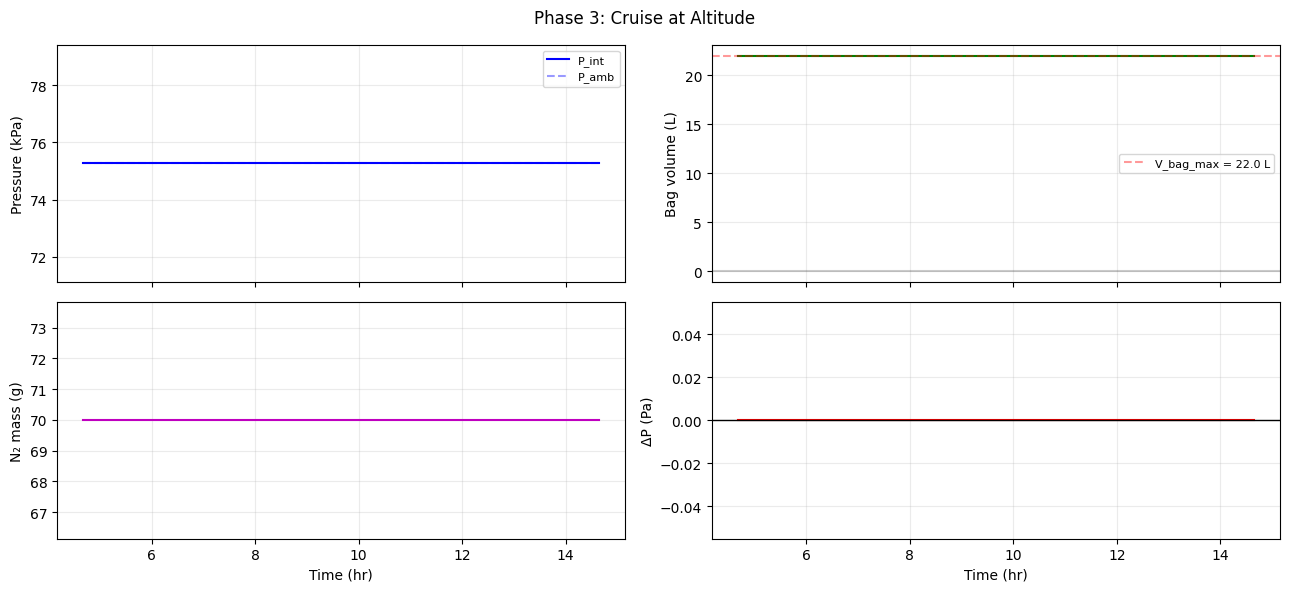

In [12]:
i_p3_start = seg_boundaries[4]
i_p3_end   = seg_boundaries[5] - 1

display(Markdown("### Phase 3 — State Table"))
display(state_table(result,
    [i_p3_start, i_p3_end],
    ["Start of cruise", "End of cruise (10 hr)"]))

show_state_eqns(result, i_p3_start, V_fixed_L)

dm3 = (result["cum_vent_kg"][i_p3_end] - result["cum_vent_kg"][i_p3_start]) * 1000
display(Markdown(f"Additional mass vented during cruise: **{dm3:.4f} g**"))

phase_plot(result, i_p3_start, i_p3_end, "Phase 3: Cruise at Altitude")

## Phase 4 — Descent (Repressurisation) ← THE CRITICAL PHASE

**Segment 6:** Ambient pressure rises from ≈ 75.3 kPa back to
101.325 kPa over 30 min.  The gas compresses, the bag contracts, and
internal pressure may — or may not — keep pace with ambient.

**This is where the failure manifests.**  If sufficient mass was lost
during outbound venting, the remaining nitrogen cannot fill $V_{fixed}$
at the returning ambient pressure once the bag collapses:

$$
P_{int,\,collapsed}
= P\!\left(T,\;\frac{m_{retained}}{V_{fixed}}\right)
< P_{amb}
\quad\Longrightarrow\quad
\Delta P < 0
\quad\Longrightarrow\quad
\text{contamination risk}
$$

**Cabin-altitude descent rate:**

$$
\frac{d(\text{alt})}{dt} = \frac{-8\,000\;\text{ft}}{30\;\text{min}}
= -267\;\text{ft/min}
$$

(slower than climb — standard practice for passenger ear comfort)

### Phase 4 — Descent State Table (fine resolution)

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,t = 14.67 hr,14.67,24.0,75.26,75.26,+0.0,0.8535,22.00,69.9867,12.7162,0.999846
1,t = 14.75 hr,14.75,24.3,79.18,79.18,+0.0,0.8969,18.03,69.9867,12.7162,0.999840
2,t = 14.85 hr,14.85,24.7,84.10,84.10,+0.0,0.9513,13.57,69.9867,12.7162,0.999833
3,t = 14.95 hr,14.95,25.1,89.26,89.26,+0.0,1.0084,9.40,69.9867,12.7162,0.999826
4,t = 15.05 hr,15.05,25.5,94.67,94.67,+0.0,1.0681,5.52,69.9867,12.7162,0.999819
5,t = 15.15 hr,15.15,25.9,100.35,100.35,+0.0,1.1307,1.90,69.9867,12.7162,0.999811


### Worst pressure deficit

**State at $t = 0.00$ hr**  ($T = 20.0$ °C, $P_{amb} = 101.33$ kPa)

$$
\rho = \rho_{\text{CP}}(293.15\;\text{K},\;101.33\;\text{kPa}) = 1.1648\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{82.7029\;\text{g}}{1.1648\;\text{kg/m³}} = 71.00\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 71.00 - 60.0 = 11.00\;\text{L}
$$

> Bag within operating range.  $P_{int} = P_{amb} = 101.33$ kPa.

$$\Delta P_{worst} = P_{int} - P_{amb} = +0.0\;\text{Pa} = +0.0000\;\text{kPa}$$

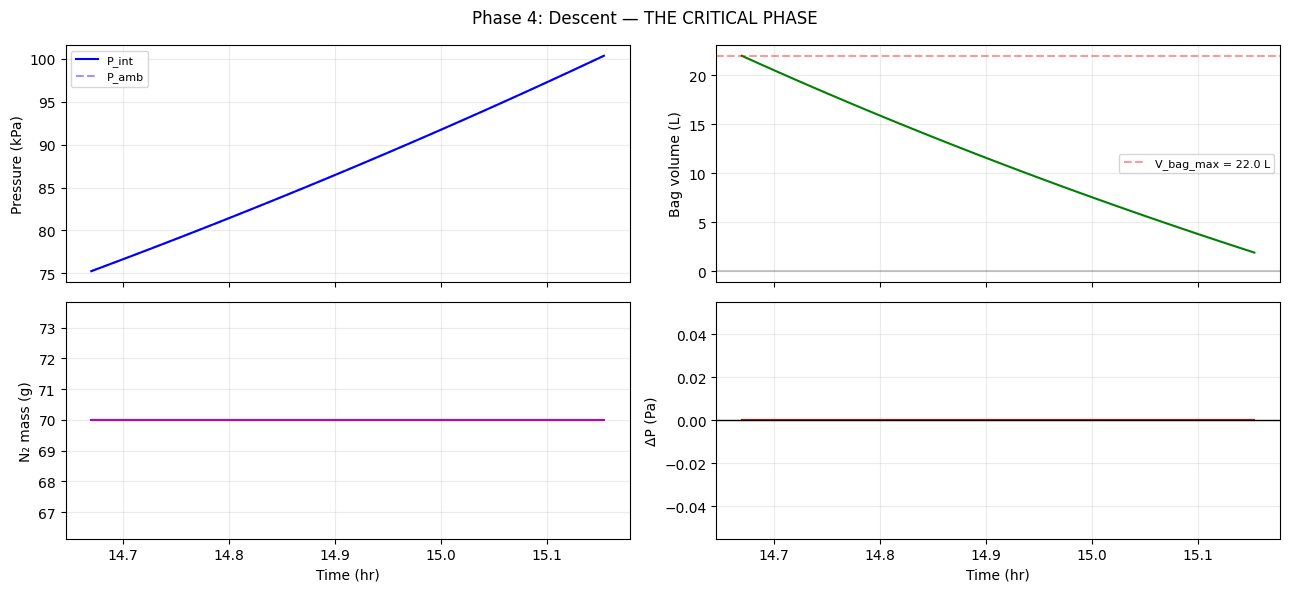

In [13]:
i_p4_start = seg_boundaries[5]
i_p4_end   = seg_boundaries[6] - 1

# Show extra points during descent — this is where the action is
n_pts = min(6, i_p4_end - i_p4_start + 1)
desc_idx = np.linspace(i_p4_start, i_p4_end, n_pts, dtype=int).tolist()
desc_lbl = [f"t = {t_hr[i]:.2f} hr" for i in desc_idx]

display(Markdown("### Phase 4 — Descent State Table (fine resolution)"))
display(state_table(result, desc_idx, desc_lbl))

if i_bag_collapse is not None and i_p4_start <= i_bag_collapse <= i_p4_end:
    display(Markdown(f"### ⚠ Bag collapse at $t = {t_hr[i_bag_collapse]:.2f}$ hr"))
    show_state_eqns(result, i_bag_collapse, V_fixed_L)

display(Markdown("### Worst pressure deficit"))
show_state_eqns(result, i_worst, V_fixed_L)

dp_worst_Pa  = result["delta_P_Pa"][i_worst]
dp_worst_kPa = dp_worst_Pa / 1000
display(Markdown(
    f"$$\\Delta P_{{worst}} = P_{{int}} - P_{{amb}} = "
    f"{dp_worst_Pa:+.1f}\\;\\text{{Pa}} = "
    f"{dp_worst_kPa:+.4f}\\;\\text{{kPa}}$$"))

phase_plot(result, i_p4_start, i_p4_end,
           "Phase 4: Descent — THE CRITICAL PHASE")

## Phase 5 — Ground Return (Isobaric Cooling to Destination)

**Segments 7–9:** After landing the assembly returns to atmospheric
pressure and gradually cools.

In the collapsed-bag regime, cooling *helps*: density increases, so
$P_{int}$ rises toward $P_{amb}$.  But the improvement is modest if
$T$ is already close to the destination temperature.

### Phase 5 — State Table

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,After landing,15.17,26.0,101.33,101.33,+0.0,1.1414,1.32,69.9867,12.7162,0.999810
1,End taxi/unload,15.67,28.0,101.33,101.33,+0.0,1.1338,1.73,69.9867,12.7162,0.999827
2,End ground transport,16.67,22.0,101.33,101.33,+0.0,1.1569,0.49,69.9867,12.7162,0.999775
3,Final (destination),18.67,20.0,101.33,101.33,+0.0,1.1648,0.08,69.9867,12.7162,0.999757


**State at $t = 18.67$ hr**  ($T = 20.0$ °C, $P_{amb} = 101.33$ kPa)

$$
\rho = \rho_{\text{CP}}(293.15\;\text{K},\;101.33\;\text{kPa}) = 1.1648\;\text{kg/m³}
$$

$$
V_{req} = \frac{m}{\rho} = \frac{69.9867\;\text{g}}{1.1648\;\text{kg/m³}} = 60.08\;\text{L}
$$

$$
V_{bag} = V_{req} - V_{fixed} = 60.08 - 60.0 = 0.08\;\text{L}
$$

> Bag within operating range.  $P_{int} = P_{amb} = 101.33$ kPa.

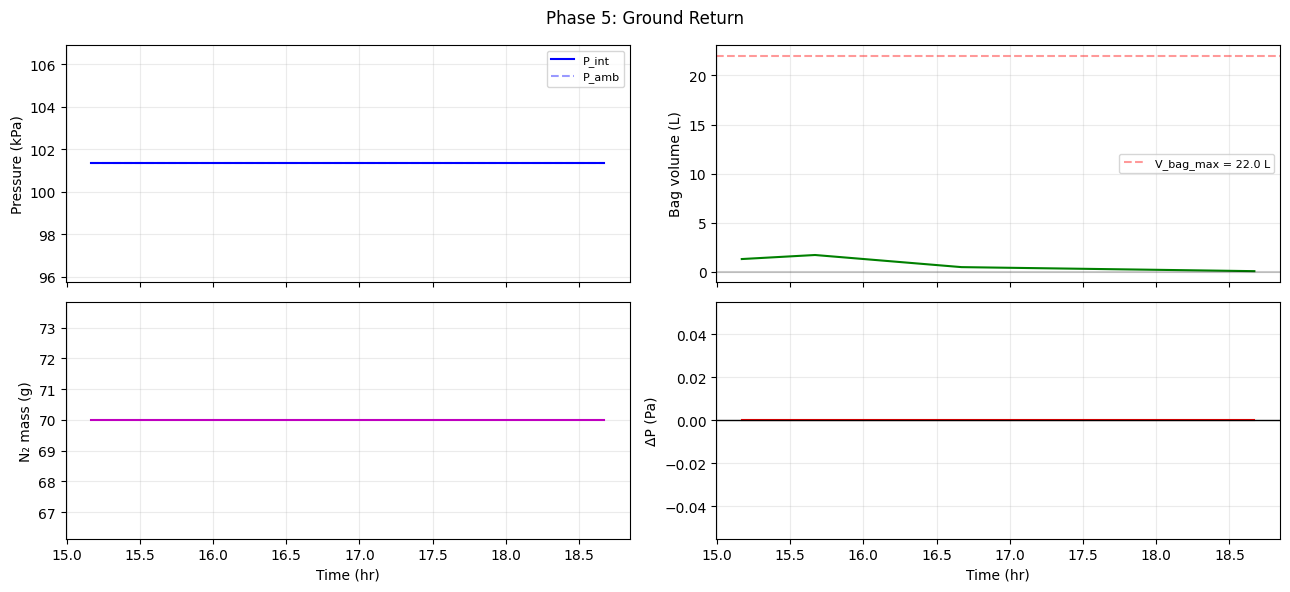

In [14]:
i_p5_start = seg_boundaries[6]
i_p5_end   = len(t_hr) - 1

display(Markdown("### Phase 5 — State Table"))
display(state_table(result,
    [i_p5_start, seg_boundaries[7], seg_boundaries[8], i_p5_end],
    ["After landing", "End taxi/unload", "End ground transport", "Final (destination)"]))

show_state_eqns(result, i_p5_end, V_fixed_L)

phase_plot(result, i_p5_start, i_p5_end, "Phase 5: Ground Return")

# 6. Full Cycle Summary

Four-panel overview of the entire shipping cycle.

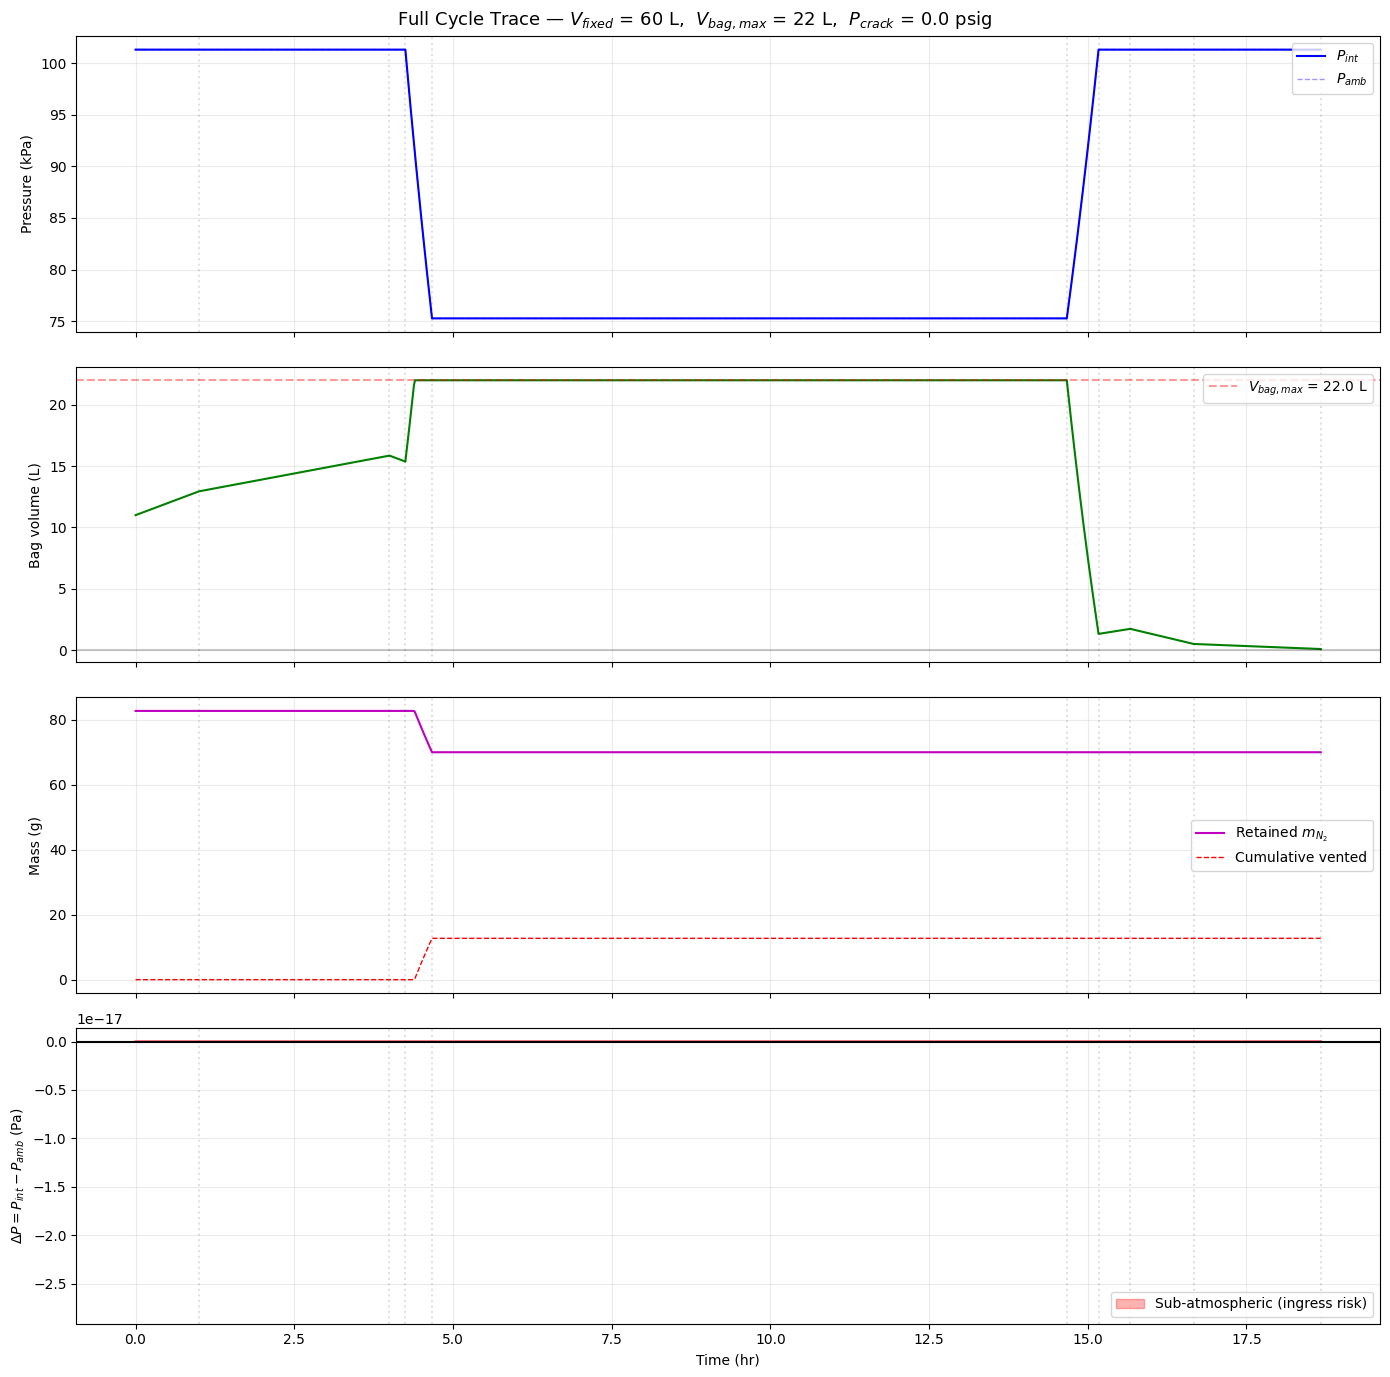

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# ── Pressure ─────────────────────────────────────────────────────────
axes[0].plot(t_hr, result["P_int_Pa"]/1000, "b-", lw=1.5, label="$P_{int}$")
axes[0].plot(t_hr, P_amb/1000, "b--", lw=1, alpha=.4, label="$P_{amb}$")
axes[0].set_ylabel("Pressure (kPa)")
axes[0].legend(loc="upper right")

# ── Bag volume ───────────────────────────────────────────────────────
axes[1].plot(t_hr, result["V_bag_m3"]*1000, "g-", lw=1.5)
axes[1].axhline(V_bag_max_L, color="r", ls="--", alpha=.4,
                label=f"$V_{{bag,max}}$ = {V_bag_max_L} L")
axes[1].axhline(0, color="k", alpha=.2)
axes[1].set_ylabel("Bag volume (L)")
axes[1].legend(loc="upper right")

# ── Mass ─────────────────────────────────────────────────────────────
axes[2].plot(t_hr, result["mass_kg"]*1000, "m-", lw=1.5, label="Retained $m_{N_2}$")
axes[2].plot(t_hr, result["cum_vent_kg"]*1000, "r--", lw=1, label="Cumulative vented")
axes[2].set_ylabel("Mass (g)")
axes[2].legend(loc="right")

# ── ΔP ───────────────────────────────────────────────────────────────
axes[3].plot(t_hr, result["delta_P_Pa"], "r-", lw=1.5)
axes[3].axhline(0, color="k", lw=1.5)
axes[3].fill_between(t_hr, result["delta_P_Pa"], 0,
                      where=result["delta_P_Pa"] < 0,
                      alpha=0.3, color="red",
                      label="Sub-atmospheric (ingress risk)")
axes[3].set_ylabel("$\\Delta P = P_{int} - P_{amb}$ (Pa)")
axes[3].set_xlabel("Time (hr)")
axes[3].legend(loc="lower right")

for ax in axes:
    for b in seg_boundaries:
        if 0 < b < len(t_hr):
            ax.axvline(t_hr[b], color="k", ls=":", alpha=.12)
    ax.grid(True, alpha=.25)

fig.suptitle(
    f"Full Cycle Trace — $V_{{fixed}}$ = {V_fixed_L:.0f} L,  "
    f"$V_{{bag,max}}$ = {V_bag_max_L:.0f} L,  "
    f"$P_{{crack}}$ = {P_crack_psig:.1f} psig",
    fontsize=13,
)
fig.tight_layout()
plt.show()

In [16]:
display(Markdown("### Key Event Summary"))
ev_idx = [v for v in events.values() if v is not None]
ev_lbl = [k for k, v in events.items() if v is not None]
display(state_table(result, ev_idx, ev_lbl))

m0_g = result["mass_kg"][0] * 1000
mf_g = result["mass_kg"][-1] * 1000
mv_g = result["cum_vent_kg"][-1] * 1000
dp_w = result["delta_P_Pa"][i_worst]

display(Markdown(f"""### Mass & Pressure Accounting

| Quantity | Value |
|:---------|------:|
| Initial N₂ mass $m_0$ | {m0_g:.4f} g |
| Final retained mass | {mf_g:.4f} g |
| Total vented | {mv_g:.4f} g ({mv_g/m0_g*100:.1f}% of initial) |
| Worst $\\Delta P$ | {dp_w:+.1f} Pa ({dp_w/1000:+.4f} kPa) |
| Worst $\\Delta P$ at | $t$ = {t_hr[i_worst]:.2f} hr |
"""))

### Key Event Summary

,State,t (hr),T (°C),P_amb (kPa),P_int (kPa),ΔP (Pa),ρ (kg/m³),V_bag (L),m_N₂ (g),Vented (g),Z
0,Seal-up,0.00,20.0,101.33,101.33,+0.0,1.1648,11.00,82.7029,0.0000,0.999757
1,Bag full,4.40,33.0,91.21,91.21,+0.0,1.0041,22.00,82.3349,0.3681,0.999879
2,Vent start,4.40,33.0,91.21,91.21,+0.0,1.0041,22.00,82.3349,0.3681,0.999879
3,Worst ΔP,0.00,20.0,101.33,101.33,+0.0,1.1648,11.00,82.7029,0.0000,0.999757
4,Final,18.67,20.0,101.33,101.33,+0.0,1.1648,0.08,69.9867,12.7162,0.999757


### Mass & Pressure Accounting

| Quantity | Value |
|:---------|------:|
| Initial N₂ mass $m_0$ | 82.7029 g |
| Final retained mass | 69.9867 g |
| Total vented | 12.7162 g (15.4% of initial) |
| Worst $\Delta P$ | +0.0 Pa (+0.0000 kPa) |
| Worst $\Delta P$ at | $t$ = 0.00 hr |


# 7. Thermodynamic State Diagrams

The nitrogen state traced on standard $T$–$s$ and $P$–$v$ coordinates.
If venting occurs the path is **open** (mass leaves the system), so the
return path does not close back to the starting point.

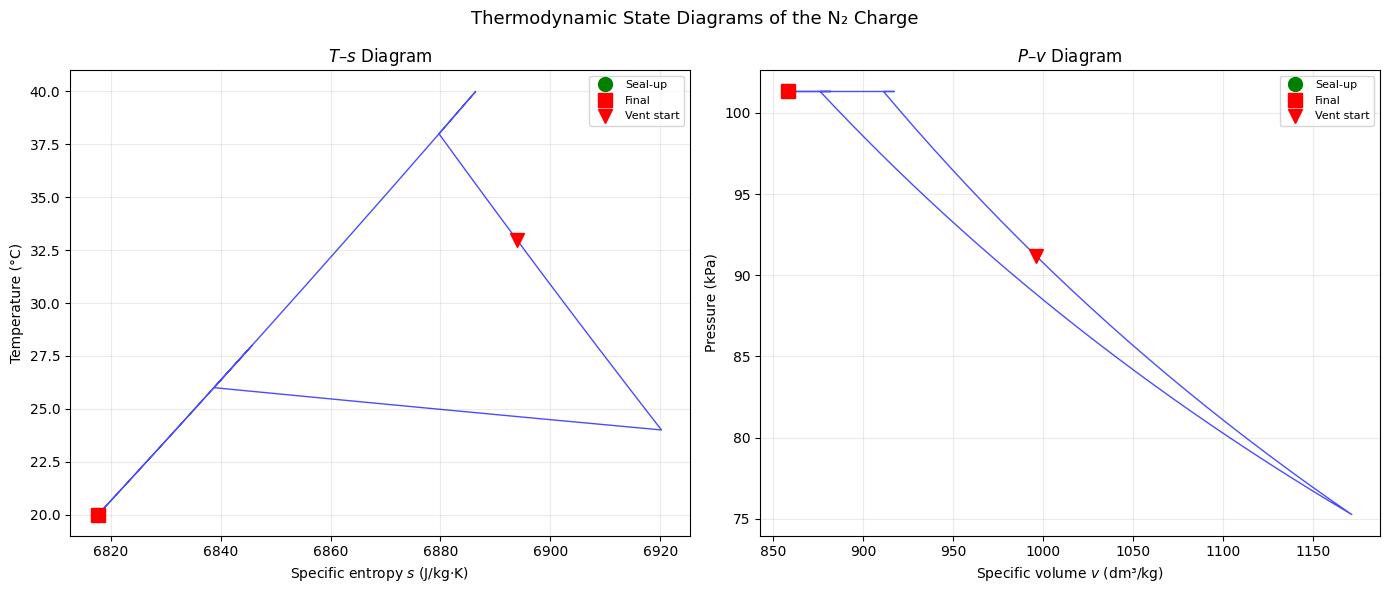

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── T-s ──────────────────────────────────────────────────────────────
axes[0].plot(result["s_J_kgK"], result["T_K"] - 273.15, "b-", lw=1, alpha=.7)
axes[0].plot(result["s_J_kgK"][0], result["T_K"][0]-273.15,
             "go", ms=10, zorder=5, label="Seal-up")
axes[0].plot(result["s_J_kgK"][-1], result["T_K"][-1]-273.15,
             "rs", ms=10, zorder=5, label="Final")
if i_vent_start is not None:
    axes[0].plot(result["s_J_kgK"][i_vent_start],
                 result["T_K"][i_vent_start]-273.15,
                 "rv", ms=10, zorder=5, label="Vent start")
if i_bag_collapse is not None:
    axes[0].plot(result["s_J_kgK"][i_bag_collapse],
                 result["T_K"][i_bag_collapse]-273.15,
                 "kx", ms=12, mew=2, zorder=5, label="Bag collapse")
axes[0].set_xlabel("Specific entropy $s$ (J/kg·K)")
axes[0].set_ylabel("Temperature (°C)")
axes[0].set_title("$T$–$s$ Diagram")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=.25)

# ── P-v ──────────────────────────────────────────────────────────────
v_spec = 1.0 / result["rho_int"]  # m³/kg
axes[1].plot(v_spec * 1000, result["P_int_Pa"]/1000, "b-", lw=1, alpha=.7)
axes[1].plot(v_spec[0]*1000, result["P_int_Pa"][0]/1000,
             "go", ms=10, zorder=5, label="Seal-up")
axes[1].plot(v_spec[-1]*1000, result["P_int_Pa"][-1]/1000,
             "rs", ms=10, zorder=5, label="Final")
if i_vent_start is not None:
    axes[1].plot(v_spec[i_vent_start]*1000,
                 result["P_int_Pa"][i_vent_start]/1000,
                 "rv", ms=10, zorder=5, label="Vent start")
if i_bag_collapse is not None:
    axes[1].plot(v_spec[i_bag_collapse]*1000,
                 result["P_int_Pa"][i_bag_collapse]/1000,
                 "kx", ms=12, mew=2, zorder=5, label="Bag collapse")
axes[1].set_xlabel("Specific volume $v$ (dm³/kg)")
axes[1].set_ylabel("Pressure (kPa)")
axes[1].set_title("$P$–$v$ Diagram")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=.25)

fig.suptitle("Thermodynamic State Diagrams of the N₂ Charge", fontsize=13)
fig.tight_layout()
plt.show()

# 8. Design-Space Sweep: $V_{fixed}$ Sensitivity

Repeat the full cycle simulation across a range of rigid connected
volumes to identify the screening thresholds.

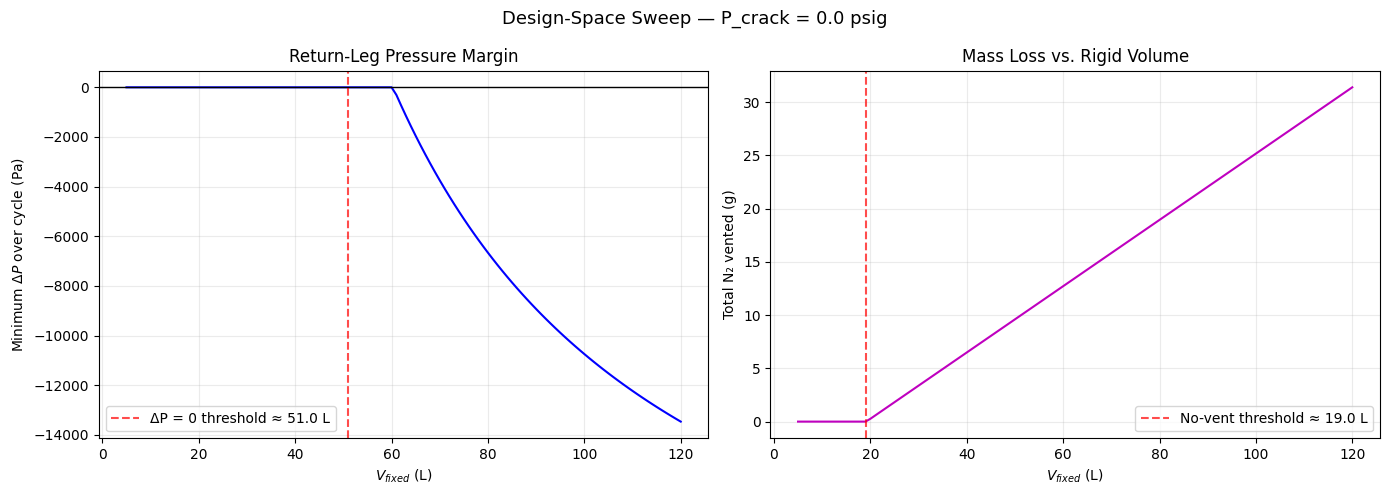

### Screening thresholds (CoolProp, realistic profile)

| Threshold | $V_{fixed}$ |
|:----------|-------------:|
| No venting | ≈ 19.0 L |
| Return $\Delta P \ge 0$ | ≈ 51.0 L |

Compare with the closed-form ideal-gas thresholds in the report
(15.28 L and 52.55 L for ideal vent).  Small differences arise from the
realistic multi-segment profile vs. the two-state bounding analysis.


In [18]:
sweep_Vf = np.linspace(5, 120, 116)   # 1-L steps
sweep_rows = []

for Vf_L in sweep_Vf:
    Vf = Vf_L * L_TO_M3
    r  = simulate(t_hr, T_K, P_amb, Vf, V_bag_init, V_bag_max, P_crack_Pa)
    sweep_rows.append({
        "V_fixed_L":       Vf_L,
        "min_dP_Pa":       r["delta_P_Pa"].min(),
        "total_vented_g":  r["cum_vent_kg"][-1] * 1000,
        "worst_t_hr":      r["t_hr"][np.argmin(r["delta_P_Pa"])],
    })

df_sweep = pd.DataFrame(sweep_rows)

# ── Threshold crossings ──────────────────────────────────────────────
V_no_vent   = None
V_threshold = None

for i in range(1, len(df_sweep)):
    row0, row1 = df_sweep.iloc[i-1], df_sweep.iloc[i]
    # No-vent threshold
    if V_no_vent is None and row0["total_vented_g"] <= 0 and row1["total_vented_g"] > 0:
        x0, x1 = row0["V_fixed_L"], row1["V_fixed_L"]
        y0, y1 = row0["total_vented_g"], row1["total_vented_g"]
        V_no_vent = x0 - y0 * (x1 - x0) / (y1 - y0)
    # Return-nonneg threshold
    if V_threshold is None and row0["min_dP_Pa"] >= 0 and row1["min_dP_Pa"] < 0:
        x0, x1 = row0["V_fixed_L"], row1["V_fixed_L"]
        y0, y1 = row0["min_dP_Pa"], row1["min_dP_Pa"]
        V_threshold = x0 - y0 * (x1 - x0) / (y1 - y0)

# ── Plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_sweep["V_fixed_L"], df_sweep["min_dP_Pa"], "b-", lw=1.5)
axes[0].axhline(0, color="k", lw=1)
if V_threshold is not None:
    axes[0].axvline(V_threshold, color="r", ls="--", alpha=.7,
                    label=f"ΔP = 0 threshold ≈ {V_threshold:.1f} L")
    axes[0].legend()
axes[0].set_xlabel("$V_{fixed}$ (L)")
axes[0].set_ylabel("Minimum $\\Delta P$ over cycle (Pa)")
axes[0].set_title("Return-Leg Pressure Margin")
axes[0].grid(True, alpha=.25)

axes[1].plot(df_sweep["V_fixed_L"], df_sweep["total_vented_g"], "m-", lw=1.5)
if V_no_vent is not None:
    axes[1].axvline(V_no_vent, color="r", ls="--", alpha=.7,
                    label=f"No-vent threshold ≈ {V_no_vent:.1f} L")
    axes[1].legend()
axes[1].set_xlabel("$V_{fixed}$ (L)")
axes[1].set_ylabel("Total N₂ vented (g)")
axes[1].set_title("Mass Loss vs. Rigid Volume")
axes[1].grid(True, alpha=.25)

fig.suptitle(f"Design-Space Sweep — P_crack = {P_crack_psig:.1f} psig", fontsize=13)
fig.tight_layout()
plt.show()

display(Markdown(f"""### Screening thresholds (CoolProp, realistic profile)

| Threshold | $V_{{fixed}}$ |
|:----------|-------------:|
| No venting | ≈ {V_no_vent:.1f} L |
| Return $\\Delta P \\ge 0$ | ≈ {V_threshold:.1f} L |

Compare with the closed-form ideal-gas thresholds in the report
(15.28 L and 52.55 L for ideal vent).  Small differences arise from the
realistic multi-segment profile vs. the two-state bounding analysis.
"""))

# 9. Multi-Case Comparison

Overlay several $V_{fixed}$ values to show the progression from safe
(small volume, no venting) through marginal to full failure.

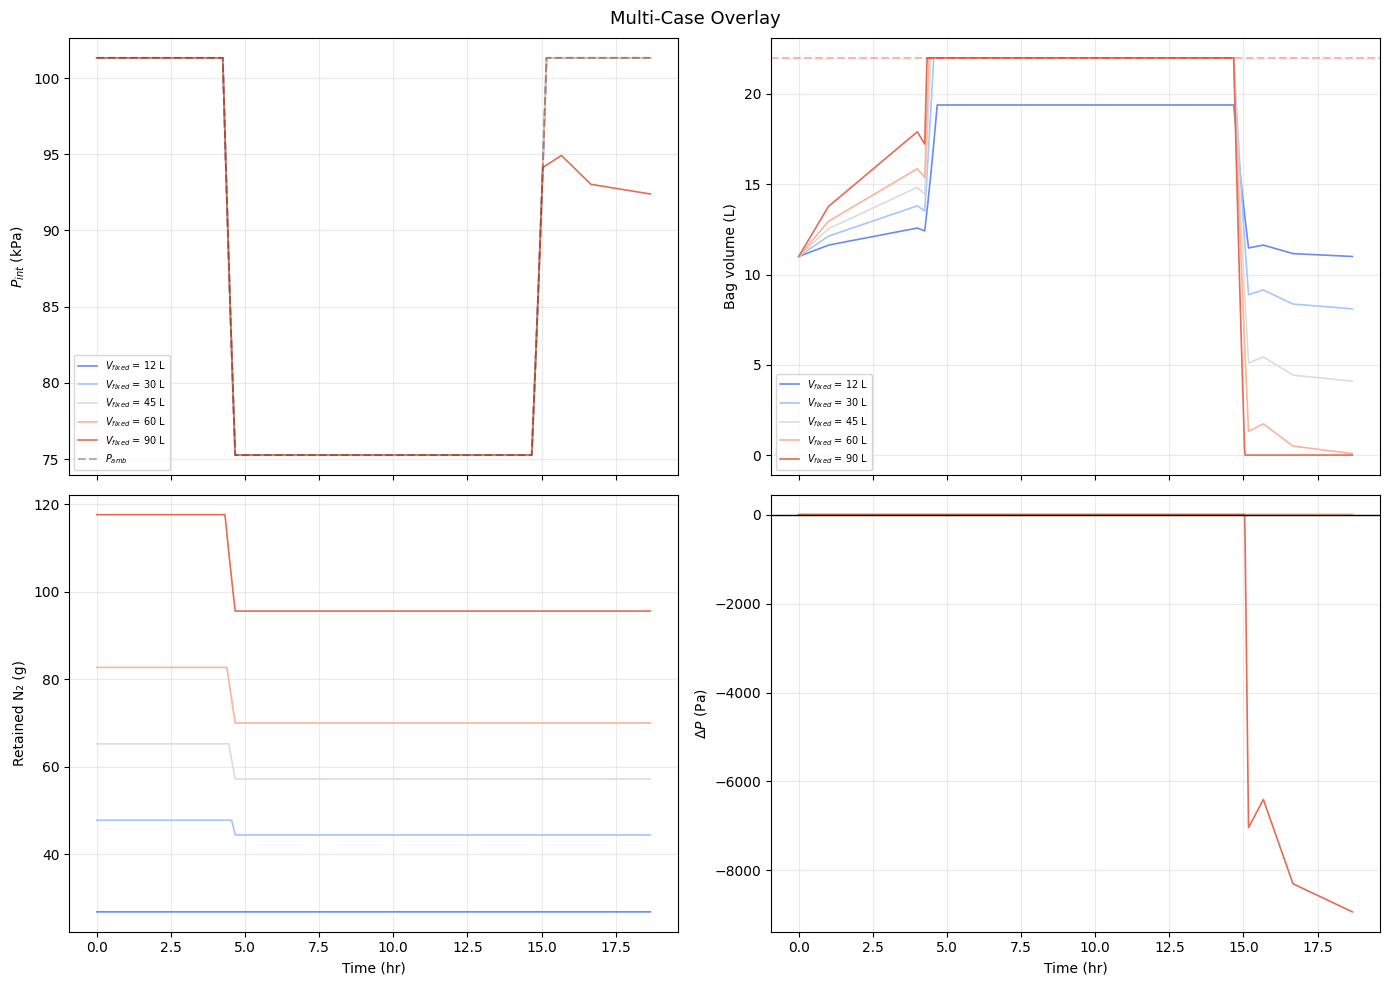

In [19]:
comparison_volumes = [12, 30, 45, 60, 90]   # L — edit to compare

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)
cmap = plt.cm.coolwarm(np.linspace(0.15, 0.85, len(comparison_volumes)))

for Vf_L, clr in zip(comparison_volumes, cmap):
    Vf = Vf_L * L_TO_M3
    r  = simulate(t_hr, T_K, P_amb, Vf, V_bag_init, V_bag_max, P_crack_Pa)
    label = f"$V_{{fixed}}$ = {Vf_L} L"

    axes[0, 0].plot(t_hr, r["P_int_Pa"]/1000, color=clr, lw=1.2, label=label)
    axes[0, 1].plot(t_hr, r["V_bag_m3"]*1000,  color=clr, lw=1.2, label=label)
    axes[1, 0].plot(t_hr, r["mass_kg"]*1000,    color=clr, lw=1.2, label=label)
    axes[1, 1].plot(t_hr, r["delta_P_Pa"],       color=clr, lw=1.2, label=label)

axes[0, 0].plot(t_hr, P_amb/1000, "k--", alpha=.3, label="$P_{amb}$")
axes[0, 0].set_ylabel("$P_{int}$ (kPa)");      axes[0, 0].legend(fontsize=7)
axes[0, 1].axhline(V_bag_max_L, color="r", ls="--", alpha=.3)
axes[0, 1].set_ylabel("Bag volume (L)");        axes[0, 1].legend(fontsize=7)
axes[1, 0].set_ylabel("Retained N₂ (g)");       axes[1, 0].set_xlabel("Time (hr)")
axes[1, 1].axhline(0, color="k", lw=1)
axes[1, 1].set_ylabel("$\\Delta P$ (Pa)");      axes[1, 1].set_xlabel("Time (hr)")

for ax in axes.flat:
    ax.grid(True, alpha=.25)

fig.suptitle("Multi-Case Overlay", fontsize=13)
fig.tight_layout()
plt.show()

# 10. Next Steps

1. **Measure $V_{fixed}$** and substitute the measured value into the
   System Parameters cell (§1).
2. **Adjust the flight profile** to match the actual shipping route —
   multi-leg connections, specific airport temperatures, seasonal
   extremes.
3. **Compare vent-valve settings** — re-run with `P_crack_psig = 2.0`
   (or other values) to see how the vent threshold shifts the design
   envelope.
4. **Explore mitigations** — add a return-leg compliance mechanism,
   increase bag size, or reduce $V_{fixed}$ by redesigning the manifold.
5. **Export figures** for inclusion in the Quarto investigation report
   (`failure-mechanism.qmd`).
6. **Promote key cells** into executable `{python}` blocks in the `.qmd`
   for a fully reproducible, self-contained report.